In [3]:
import importlib
from RSA_nD_tuner import *
import RSA_nD_tuner
importlib.reload(RSA_nD_tuner)
from RSA_nD_tuner import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

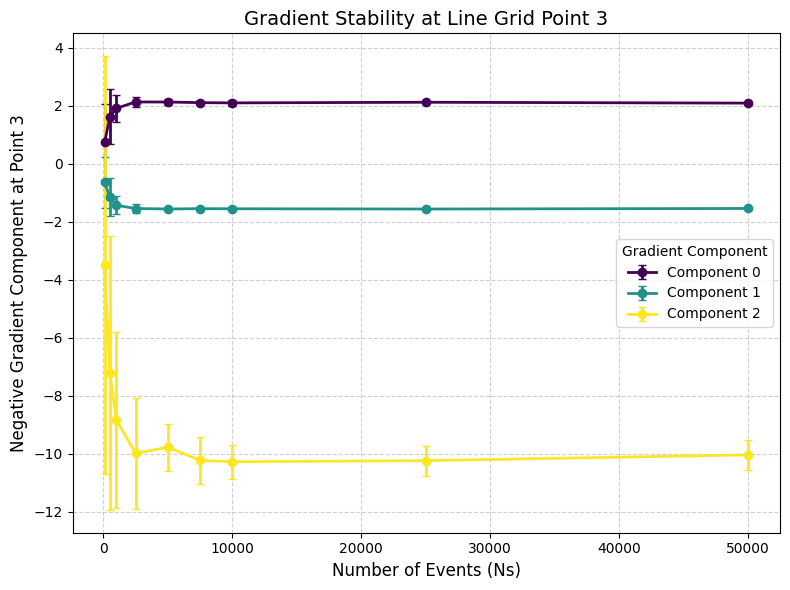

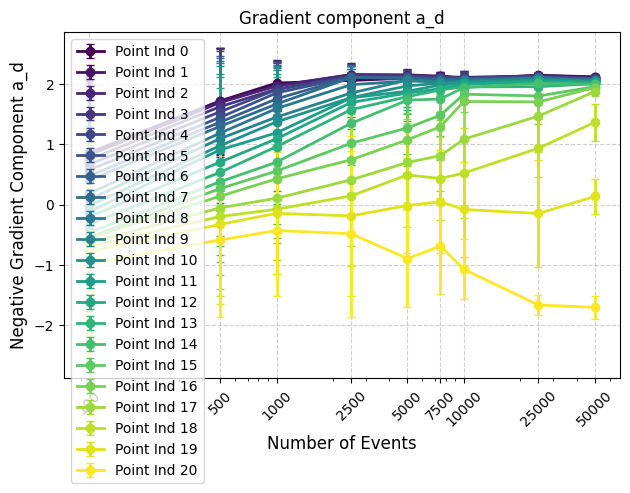

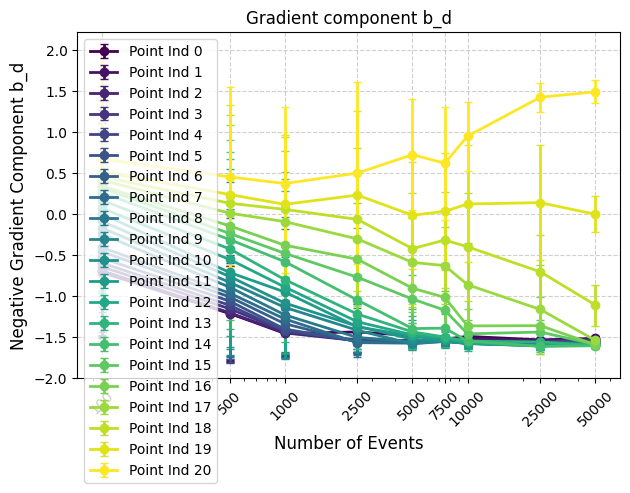

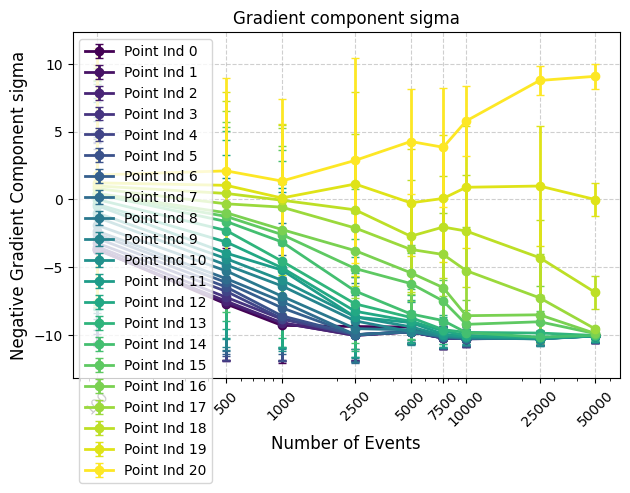

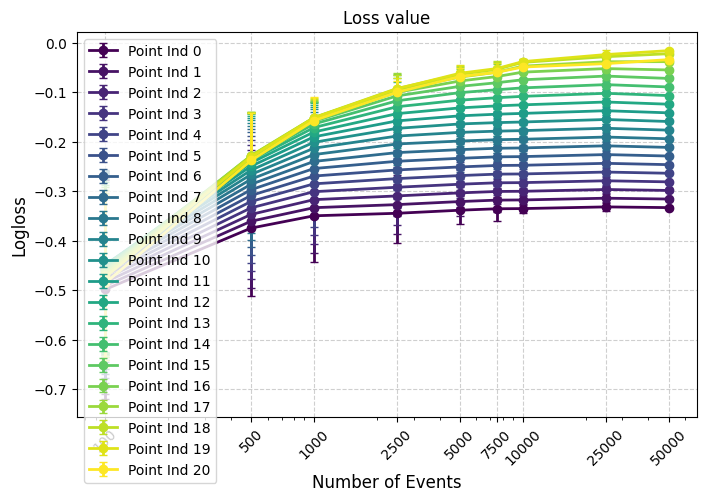

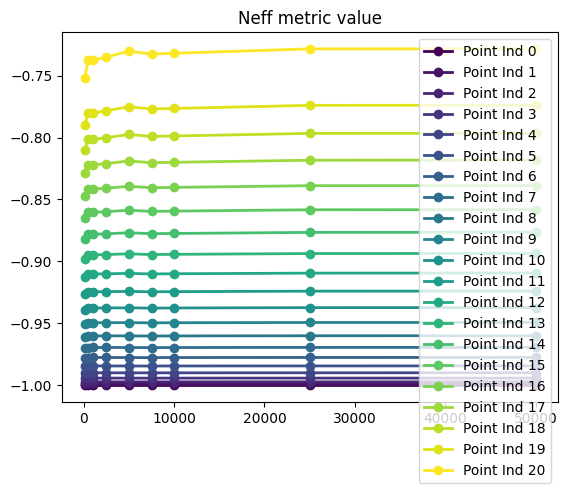

In [4]:
# Combine multiple simulated data
# Look at grad_stability/data_description.txt for description of data

plt_nm = 5
all_gradients_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_gradients{plt_nm}.npy',allow_pickle=True)
all_loss_grid_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_loss_grid{plt_nm}.npy', allow_pickle=True)
all_metrics_mu_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
all_metrics_Neff_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
Ns = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_Ns{plt_nm}.npy', allow_pickle=True)
line_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_line_grid{plt_nm}.npy', allow_pickle=True)

all_gradients = np.array([np.mean(np.array(a_g, dtype=float),axis=0) for a_g in all_gradients_load])
all_gradients_std = np.array([np.std(np.array(a_g, dtype=float),axis=0) for a_g in all_gradients_load])
all_loss_grid = np.array([np.mean(np.array(a_l, dtype=float),axis=0) for a_l in all_loss_grid_load])
all_loss_grid_std = np.array([np.std(np.array(a_l, dtype=float),axis=0) for a_l in all_loss_grid_load])
all_metrics_mu = np.array([np.mean(np.array(a_m, dtype=float),axis=0) for a_m in all_metrics_mu_load])
all_metrics_mu_std = np.array([np.std(np.array(a_m, dtype=float),axis=0) for a_m in all_metrics_mu_load])
all_metrics_Neff = np.array([np.mean(np.array(a_m, dtype=float),axis=0) for a_m in all_metrics_Neff_load])
all_metrics_Neff_std = np.array([np.std(np.array(a_m, dtype=float),axis=0) for a_m in all_metrics_Neff_load])


# Plot different components of gradient for chosen point on line grid
plt.figure(figsize=(8, 6))
point = 3

num_lines = np.shape(all_gradients)[2]
colors = cm.viridis(np.linspace(0, 1, num_lines))  # Get N colors from viridis

for i in range(num_lines):
    # print(-all_gradients[:, point, i])
    plt.errorbar(Ns, -all_gradients[:, point, i],
                 yerr=all_gradients_std[:, point, i],
                 color=colors[i], label=f'Component {i}', fmt='-o', capsize=3, linewidth=2)

# Prettify
plt.xlabel('Number of Events (Ns)', fontsize=12)
plt.ylabel(f'Negative Gradient Component at Point {point}', fontsize=12)
plt.title(f'Gradient Stability at Line Grid Point {point}', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Gradient Component', fontsize=10)
plt.tight_layout()
plt.tick_params(labelsize=10)

# Plot chosen grad component of gradient for all points on line grid
grads = ['a_d', 'b_d', 'sigma']
for grad in [0,1,2]:
    plt.figure()
    num_lines = np.shape(all_gradients)[1]
    colors = cm.viridis(np.linspace(0, 1, num_lines))  # Get N colors from viridis

    for i in range(np.shape(all_gradients)[1]):
        # plt.plot(Ns, -all_gradients[:,i,grad],'-o',color=colors[i], label=f'{i}')
        plt.errorbar(Ns, -all_gradients[:, i, grad],
                yerr=all_gradients_std[:, i, grad],
                color=colors[i], label=f'Point Ind {i}', fmt='-o', capsize=3, linewidth=2)
    plt.title(f'Gradient component {grads[grad]}')
    plt.legend()
    plt.xscale('log')
    plt.xticks(np.array(Ns, dtype=float), labels=[str(val) for val in Ns], rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Number of Events', fontsize=12)
    plt.ylabel(f'Negative Gradient Component {grads[grad]}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/plots/{plt_nm}_grad{grads[grad]}_Neff.png', dpi=300)

    # plt.savefig('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/grad_stability_grad'+str(grads[grad])+'.png', dpi=300)

# Plot loss value for all points on line grid
plt.figure(figsize=((8,5)))
num_lines = np.shape(all_gradients)[1]
colors = cm.viridis(np.linspace(0, 1, num_lines)) 
# print(np.shape(all_loss_grid))
for i in range(np.shape(all_loss_grid)[1]):
    # plt.plot(Ns, all_loss_grid[:,i], label=f'{i}',color=colors[i])
    plt.errorbar(Ns, -all_loss_grid[:, i],
        yerr=all_loss_grid_std[:, i],
        color=colors[i], label=f'Point Ind {i}', fmt='-o', capsize=3, linewidth=2)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xscale('log')
plt.xticks(np.array(Ns, dtype=float), labels=[str(val) for val in Ns], rotation=45)
plt.xlabel('Number of Events', fontsize=12)
plt.ylabel('Logloss', fontsize=12)
plt.title('Loss value')
plt.savefig(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/plots/{plt_nm}_loss.png', dpi=300)

# Plot metrics value for all points on line grid
plt.figure()
colors = cm.viridis(np.linspace(0, 1, num_lines)) 
for i in range(np.shape(all_metrics_Neff)[1]):
    # plt.plot(Ns, all_metrics_Neff[:,i], label=f'{i}', color=colors[i])
    plt.errorbar(Ns, -all_metrics_Neff[:, i],
        # yerr=all_metrics_Neff[:, i],
        color=colors[i], label=f'Point Ind {i}', fmt='-o', capsize=3, linewidth=2)
plt.legend()
plt.title('Neff metric value')
plt.savefig(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/plots/{plt_nm}_Neff.png', dpi=300)



(9, 2)
[(100, np.float64(-3.484872396290302)), (500, np.float64(-7.217583631277084)), (1000, np.float64(-8.82945066690445)), (2500, np.float64(-9.986964988708497)), (5000, np.float64(-9.77656421661377)), (7500, np.float64(-10.229823780059814)), (10000, np.float64(-10.275228023529053)), (25000, np.float64(-10.239179611206055)), (50000, np.float64(-10.039411862691244))]


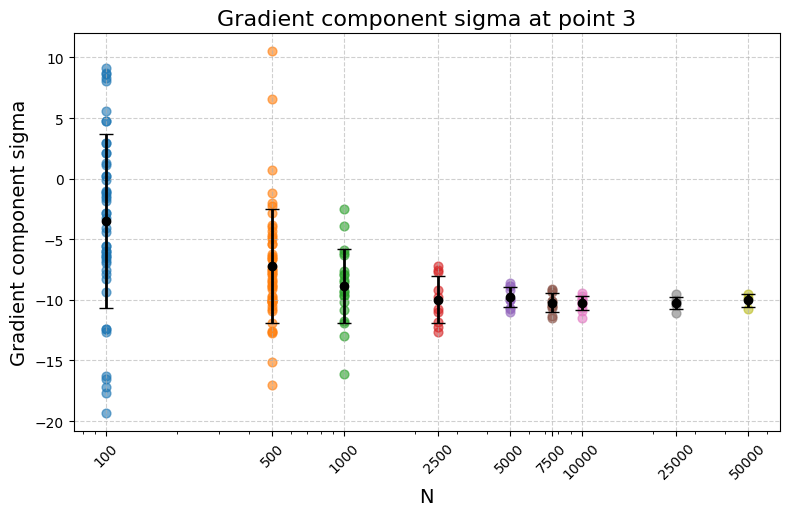

In [3]:

# plt_nm = 2
all_gradients_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_gradients{plt_nm}.npy',allow_pickle=True)
all_loss_grid_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_loss_grid{plt_nm}.npy', allow_pickle=True)
all_metrics_mu_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
all_metrics_Neff_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
Ns = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_Ns{plt_nm}.npy', allow_pickle=True)
line_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_line_grid{plt_nm}.npy', allow_pickle=True)


all_grads = []
all_loss_grid = []
all_metrics_mu = []
all_metrics_Neff = []

# print(Ns)
# print(np.shape(all_gradients_load))

# grad = 2
# point = 3
# plt.figure()
# for ind,N_gs in enumerate(all_gradients_load):
#     N = Ns[ind]
#     N_gs = -np.array(N_gs, dtype=float)
#     N = np.broadcast_to(N, N_gs[:,point,grad].shape)
#     plt.scatter(N,  N_gs[:,point,grad])
#     # print(N_gs)
#     # print(N_gs[:,point,grad])
#     print(np.mean(N_gs[:,point,grad]))


grad = 2
point = 3

plt.figure(figsize=(8, 5))

means = []
stds = []

for ind, N_gs in enumerate(all_gradients_load):
    N = Ns[ind]
    N_gs = -np.array(N_gs, dtype=float)  # negate if needed
    values = N_gs[:, point, grad]
    
    N_array = np.full_like(values, N, dtype=float)
    
    # Scatter individual runs
    plt.scatter(N_array, values, alpha=0.6, label=f'N={N}', s=40)

    # Compute mean and std
    mean_val = np.mean(values)
    std_val = np.std(values)
    means.append((N, mean_val))
    stds.append((N, std_val))

    # Plot mean ± std
    plt.errorbar(N, mean_val, yerr=std_val, fmt='o', color='black', capsize=5, lw=2)

# Sort mean/std by N for better line plotting if needed
means = sorted(means)
stds = sorted(stds)

print(np.shape(means))
print(means)

# Labels and styling
plt.xlabel('N', fontsize=14)
plt.ylabel(f'Gradient component {grads[grad]}', fontsize=14)
plt.title(f'Gradient component {grads[grad]} at point {point}', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.legend(title="Individual runs", loc='best', fontsize=10)
plt.xscale('log')
plt.xticks(np.array(Ns, dtype=float), labels=[str(val) for val in Ns], rotation=45)
plt.savefig(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/plots/{plt_nm}_grad{grad}_point{point}.png', dpi=300)
plt.show()


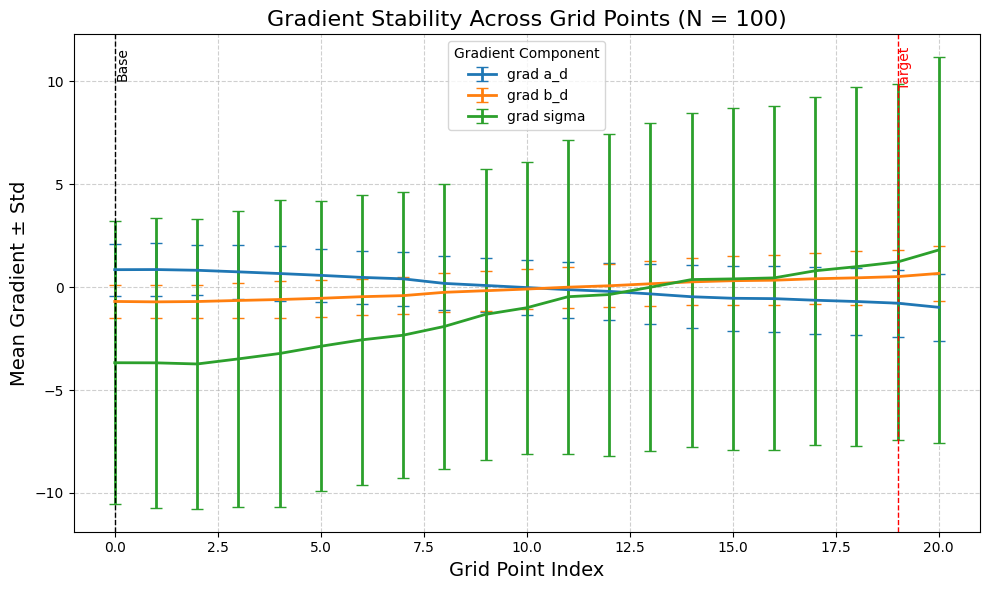

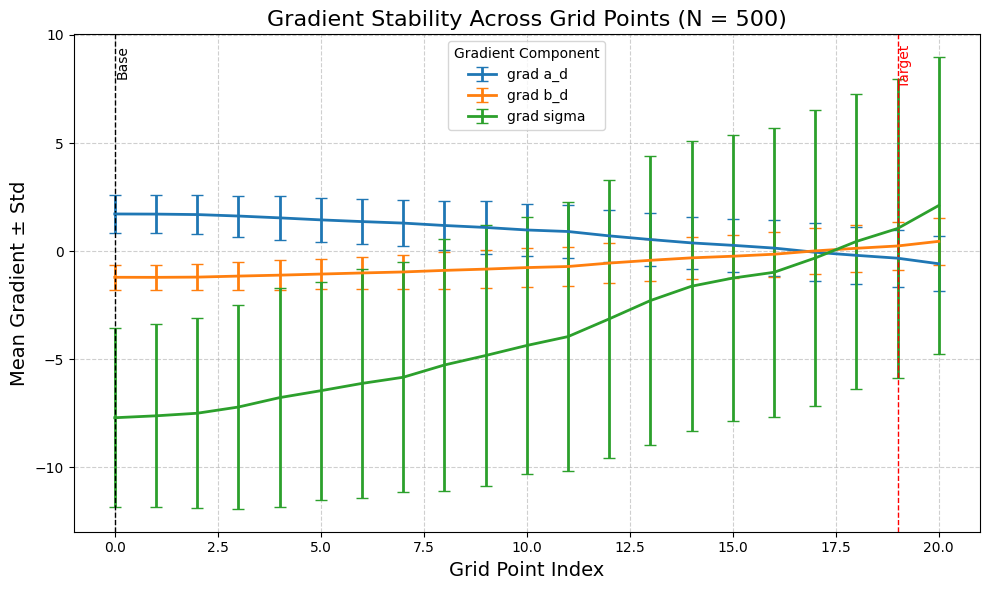

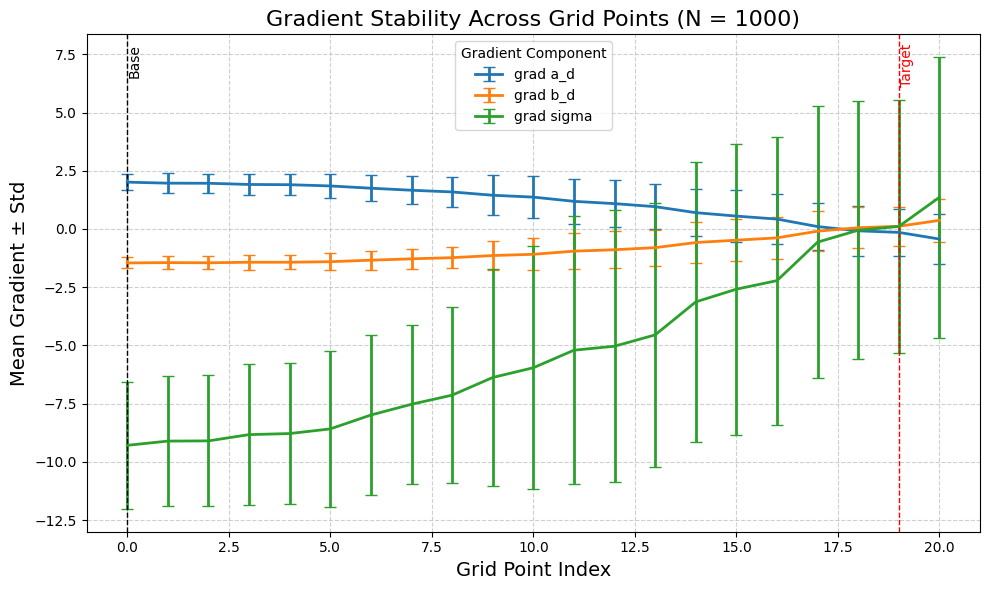

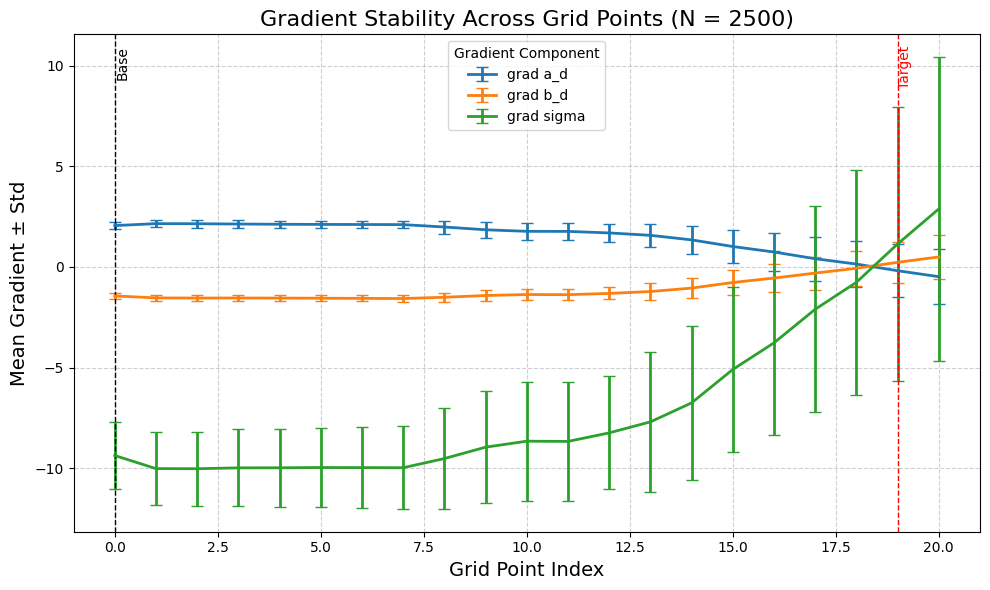

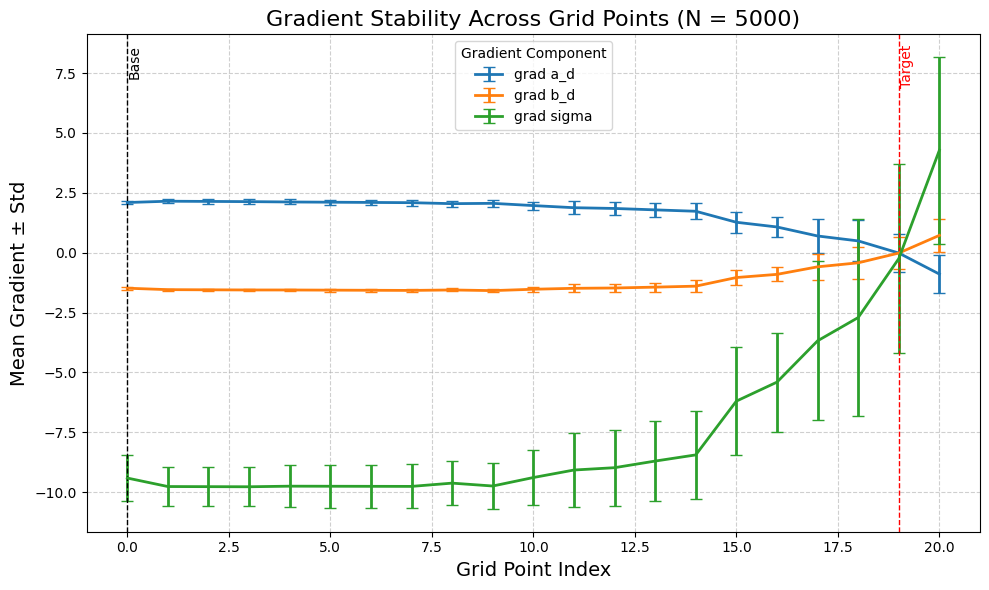

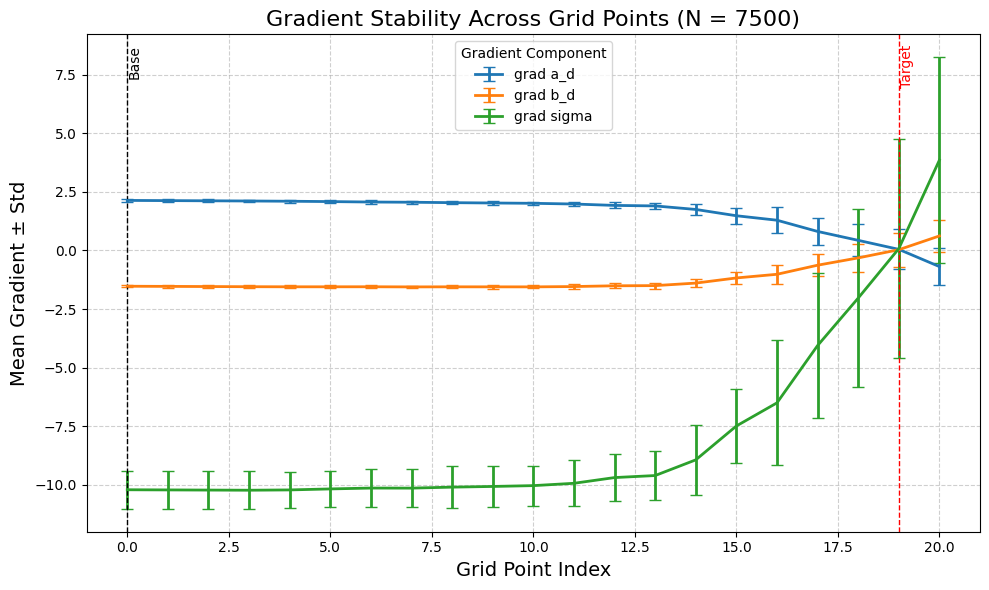

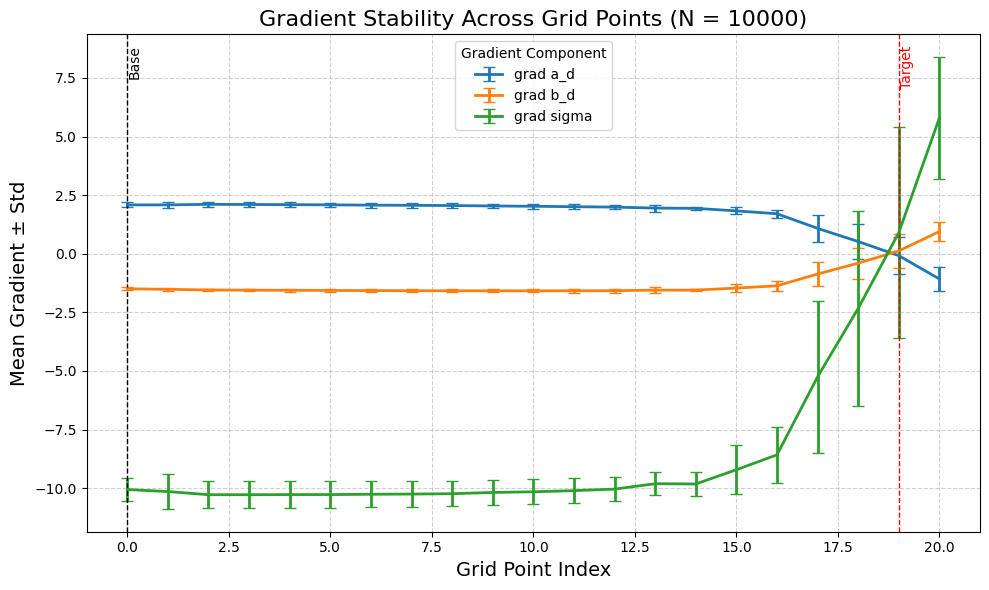

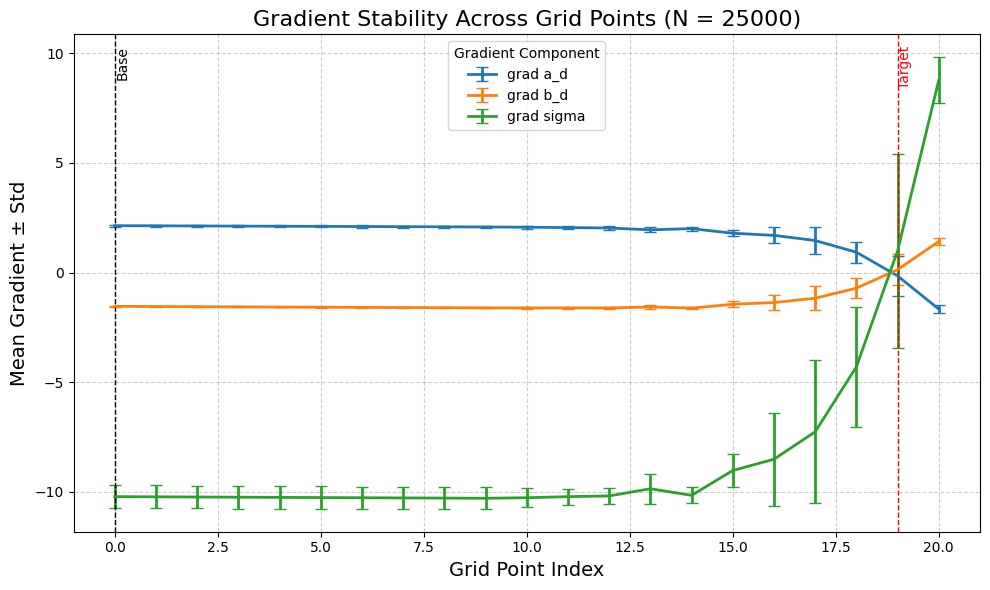

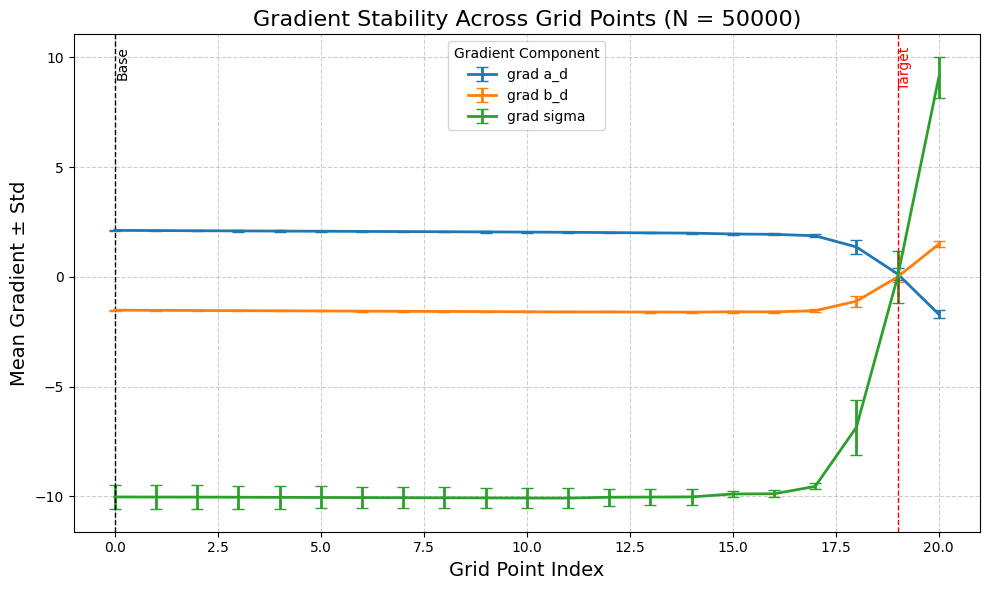

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

grad_names = ['a_d', 'b_d', 'sigma']

# Initialize storage for each N
means_by_N = defaultdict(lambda: [])
stds_by_N = defaultdict(lambda: [])

num_points = all_gradients_load[0][0].shape[0]
num_grads = all_gradients_load[0][0].shape[1]

for ind, N_gs in enumerate(all_gradients_load):
    N = Ns[ind]
    N_gs = -np.array(N_gs, dtype=float)  # (num_runs, num_points, num_grads)

    # Allocate arrays: shape (num_points, num_grads)
    means = np.mean(N_gs, axis=0)  # over runs
    stds = np.std(N_gs, axis=0)

    means_by_N[N] = means  # shape: (num_points, num_grads)
    stds_by_N[N] = stds

# Now plot for each N
for N in sorted(means_by_N.keys()):
    mean_arr = means_by_N[N]  # shape: (num_points, num_grads)
    std_arr = stds_by_N[N]

    plt.figure(figsize=(10, 6))
    x = np.arange(num_points)

    for grad in range(num_grads):
        y = mean_arr[:, grad]
        yerr = std_arr[:, grad]
        plt.errorbar(x, y, yerr=yerr, label=f'grad {grad_names[grad]}', capsize=4, lw=2)

    target_index = x[-2]  # <-- Change this to your actual target index
    plt.axvline(x=target_index, color='red', linestyle='--', linewidth=1)
    plt.text(target_index + 0.02, plt.ylim()[1]*0.95, 'Target', color='red', rotation=90, va='top')

    target_index = 0  # <-- Change this to your actual target index
    plt.axvline(x=target_index, color='black', linestyle='--', linewidth=1)
    plt.text(target_index + 0.02, plt.ylim()[1]*0.95, 'Base', color='black', rotation=90, va='top')

    plt.xlabel('Grid Point Index', fontsize=14)
    plt.ylabel('Mean Gradient ± Std', fontsize=14)
    plt.title(f'Gradient Stability Across Grid Points (N = {N})', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Gradient Component", fontsize=10)
    plt.tight_layout()

    
    plt.savefig(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/plots/{plt_nm}_grad_stability_N{N}.png', dpi=300)
    plt.show()

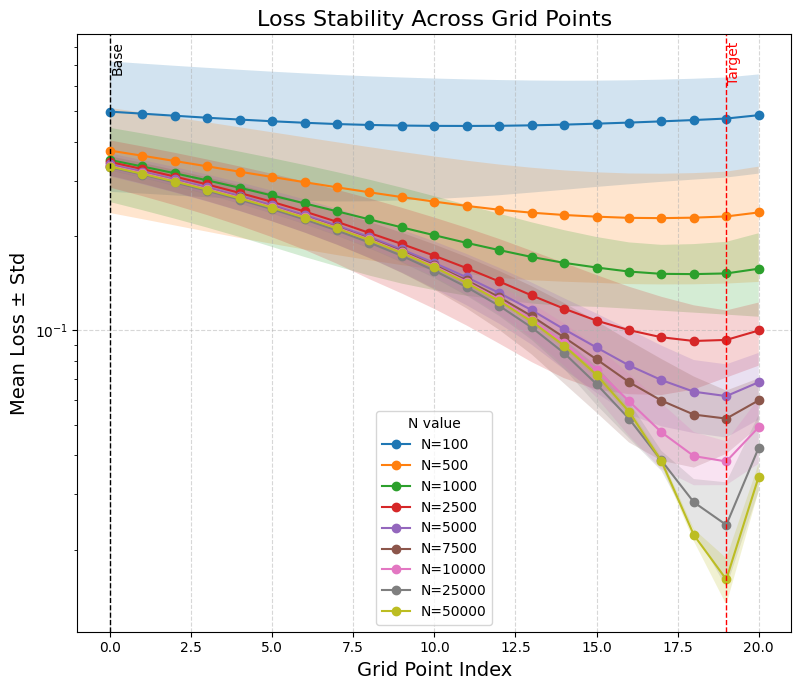

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict


all_gradients_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_gradients{plt_nm}.npy',allow_pickle=True)
all_loss_grid_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_loss_grid{plt_nm}.npy', allow_pickle=True)
all_metrics_mu_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
all_metrics_Neff_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
Ns = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_Ns{plt_nm}.npy', allow_pickle=True)
line_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_line_grid{plt_nm}.npy', allow_pickle=True)



# 1) Compute mean/std per N
means_loss = OrderedDict()
stds_loss  = OrderedDict()

n_points   = np.array(all_loss_grid_load[0]).shape[1]

for N, runs in zip(Ns, all_loss_grid_load):
    arr = np.array(runs, dtype=float)      # shape (n_runs, n_points)
    means_loss[N] = arr.mean(axis=0)       # shape (n_points,)
    stds_loss[N]  = arr.std(axis=0)        # shape (n_points,)

# 2) Plot all N on one figure
plt.figure(figsize=(8, 7))
x = np.arange(n_points)

for N in means_loss:
    y    = means_loss[N]
    yerr = stds_loss[N]
    plt.plot(x, y, '-o', label=f'N={N}')
    # optional shading:
    plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)

plt.xlabel('Grid Point Index', fontsize=14)
plt.ylabel('Mean Loss ± Std',   fontsize=14)
plt.title('Loss Stability Across Grid Points', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='N value', fontsize=10)
plt.tight_layout()
plt.yscale('log')
target_index = x[-2]  # <-- Change this to your actual target index
plt.axvline(x=target_index, color='red', linestyle='--', linewidth=1)
plt.text(target_index + 0.02, plt.ylim()[1]*0.95, 'Target', color='red', rotation=90, va='top')

base_index = 0  # <-- Change this to your actual base index
plt.axvline(x=base_index, color='black', linestyle='--', linewidth=1)
plt.text(base_index + 0.02, plt.ylim()[1]*0.95, 'Base', color='black', rotation=90, va='top')
plt.savefig(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/plots/{plt_nm}_grad_stab_loss.png', dpi=300)
plt.show()


In [ ]:
# # Plot only one set of simulated data

# plt_nm = 3
# all_gradients = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_gradients{plt_nm}.npy')
# all_loss_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_loss_grid{plt_nm}.npy')
# all_metrics_mu = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
# all_metrics_Neff = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
# Ns = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Ns{plt_nm}.npy', allow_pickle=True)
# line_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_line_grid{plt_nm}.npy', allow_pickle=True)

# # Plot different components of gradient for chosen point on line grid
# plt.figure()
# point = 0
# for i in range(np.shape(all_gradients)[2]):
#     plt.plot(Ns, -all_gradients[:,point,i],'-o', label=f'{i}')
# plt.legend()

# # Plot chosen grad component of gradient for all points on line grid
# plt.figure()
# grad = 2
# for i in range(np.shape(all_gradients)[1]):
#     plt.plot(Ns, -all_gradients[:,i,grad],'-o', label=f'{i}')
# plt.legend()

# # Plot loss value for all points on line grid
# plt.figure()
# for i in range(np.shape(all_loss_grid)[1]):
#     plt.plot(Ns, all_loss_grid[:,i], label=f'{i}')
# plt.legend()

# # Plot metrics value for all points on line grid
# plt.figure()
# for i in range(np.shape(all_metrics_Neff)[1]):
#     plt.plot(Ns, all_metrics_Neff[:,i], label=f'{i}')
# plt.legend()



0
1
2
3
4
5
6
7
8


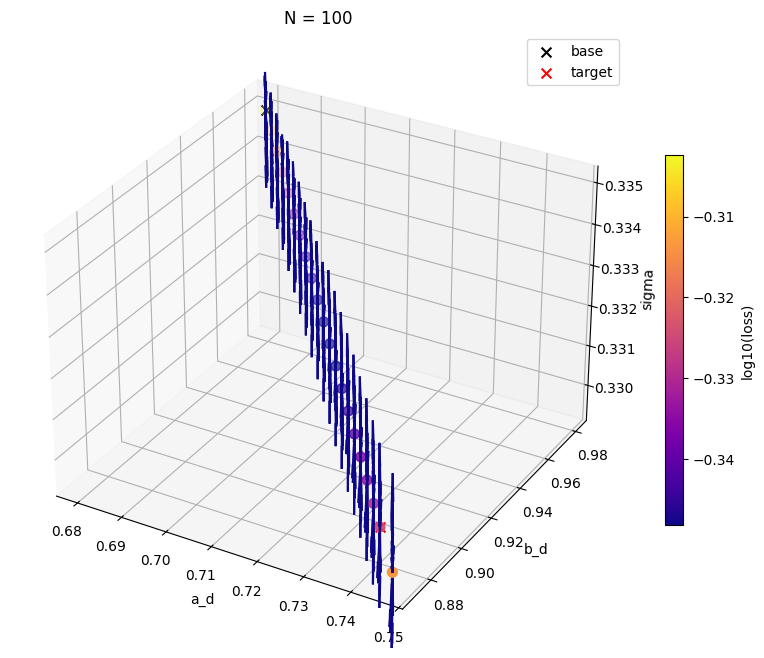

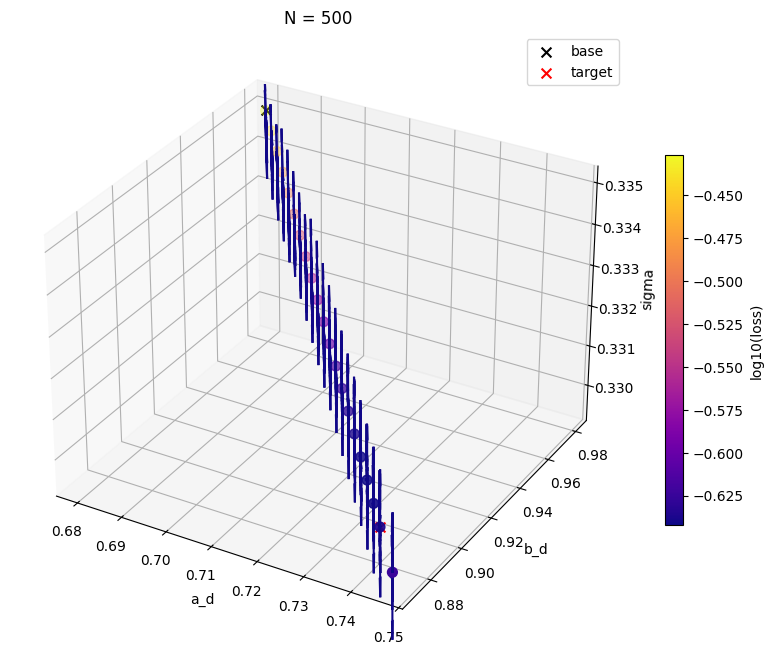

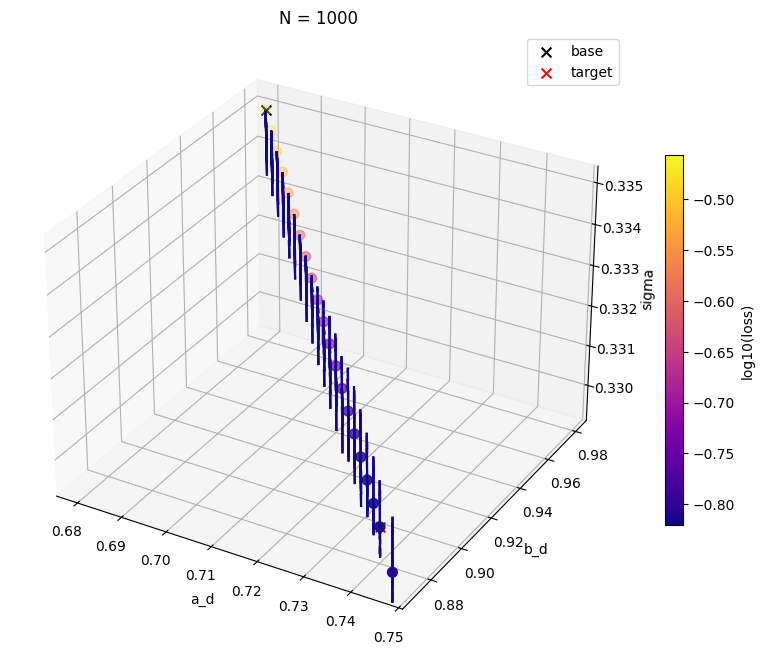

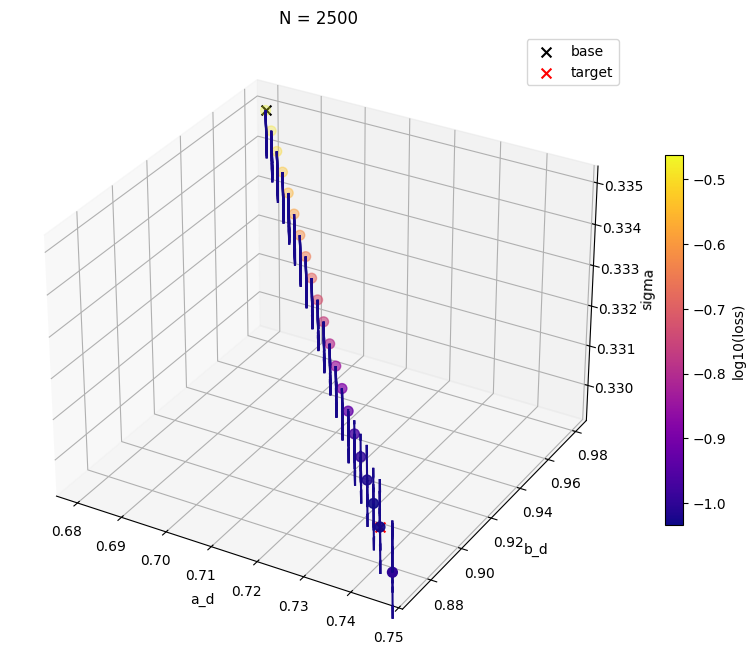

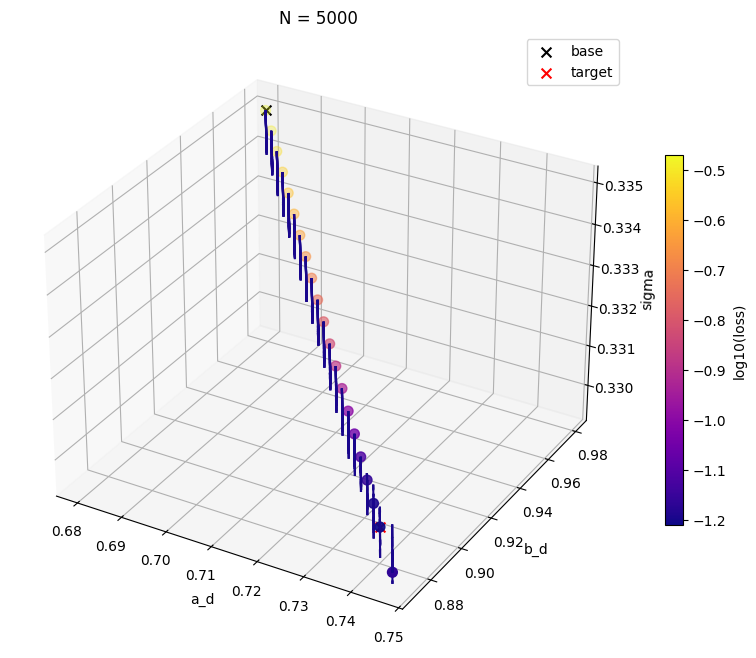

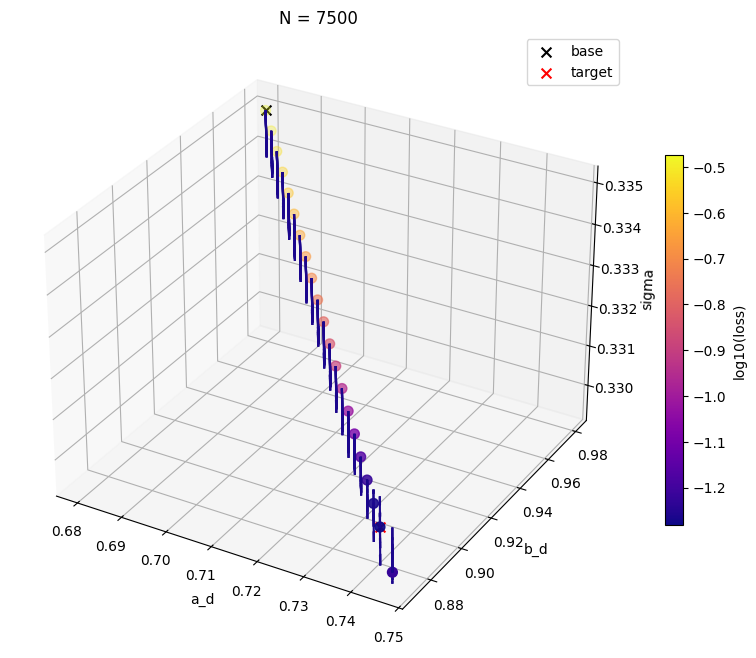

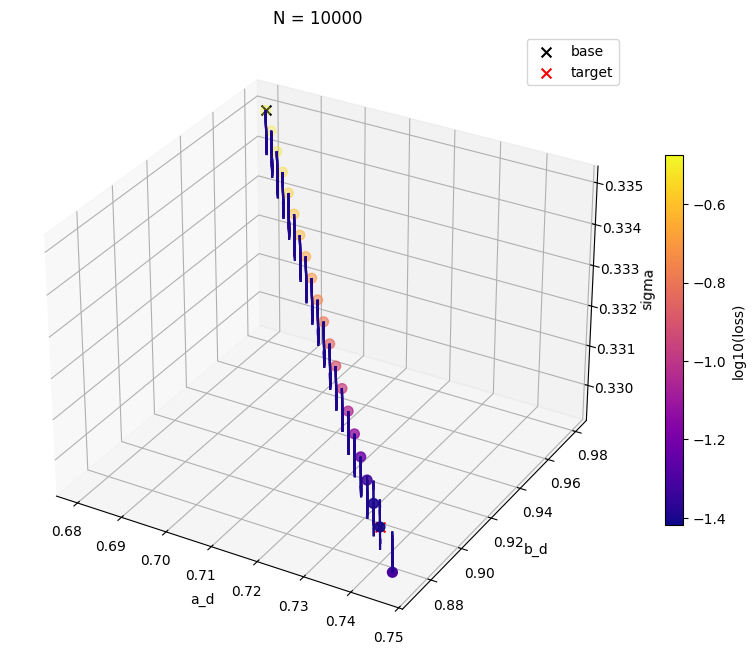

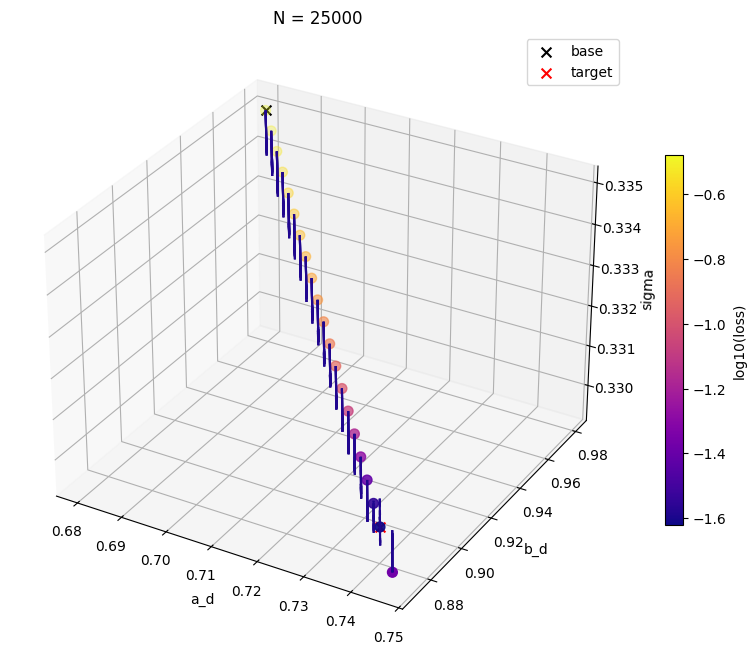

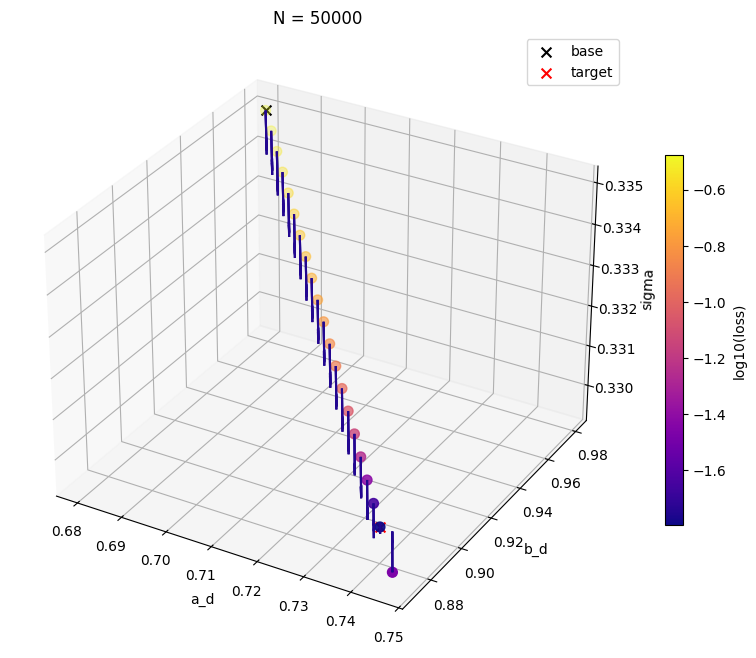

In [8]:
# Plot gradients for points on line_grid in 3D

plot_configs = {
    # '1':{'scale':3e3,'head_width':0.003,'head_length':0.003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.78,'b':0.88,'sigma':0.335}},
    '2':{'scale':3e3,'head_width':0.003,'head_length':0.003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.78,'b':0.88,'sigma':0.33}},
    '3':{'scale':3e3,'head_width':0.003,'head_length':0.003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
    '5':{'scale':3e3,'head_width':0.003,'head_length':0.003,'base':{'a':0.68,'b':0.98,'sigma':0.335},'target':{'a':0.74,'b':0.88,'sigma':0.33}},
}
config = plot_configs.get(str(plt_nm))
if config is None:
    raise ValueError(f"Unsupported plot_nm: {plt_nm}")

all_gradients_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_gradients{plt_nm}.npy',allow_pickle=True)
all_loss_grid_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_loss_grid{plt_nm}.npy', allow_pickle=True)
all_metrics_mu_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
all_metrics_Neff_load = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
Ns = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_Ns{plt_nm}.npy', allow_pickle=True)
line_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/all_line_grid{plt_nm}.npy', allow_pickle=True)

all_gradients = np.array([np.mean(np.array(a_g, dtype=float),axis=0) for a_g in all_gradients_load])
all_gradients_std = np.array([np.std(np.array(a_g, dtype=float),axis=0) for a_g in all_gradients_load])
all_loss_grid = np.array([np.mean(np.array(a_l, dtype=float),axis=0) for a_l in all_loss_grid_load])
all_loss_grid_std = np.array([np.std(np.array(a_l, dtype=float),axis=0) for a_l in all_loss_grid_load])
all_metrics_mu = np.array([np.mean(np.array(a_m, dtype=float),axis=0) for a_m in all_metrics_mu_load])
all_metrics_mu_std = np.array([np.std(np.array(a_m, dtype=float),axis=0) for a_m in all_metrics_mu_load])
all_metrics_Neff = np.array([np.mean(np.array(a_m, dtype=float),axis=0) for a_m in all_metrics_Neff_load])
all_metrics_Neff_std = np.array([np.std(np.array(a_m, dtype=float),axis=0) for a_m in all_metrics_Neff_load])

a_b_c = line_grid

cmap = plt.get_cmap('plasma')
# Normalize the magnitudes to [0, 1] for color mapping
norm = mcolors.Normalize(vmin=0, vmax=np.shape(all_gradients)[1])


for ind, N in enumerate(Ns):
    print(ind)
    fig = plt.figure(figsize=(10, 8))

    a_b_gradients = np.array(all_gradients_load[ind], dtype=float)
    loss_grid = np.array(all_loss_grid_load[ind], dtype=float)
    loss_grid = np.mean(loss_grid, axis=0)
    loss_grid = np.log10(loss_grid)
    loss_grid = np.array([float(i) for i in loss_grid])




    ax = fig.add_subplot(111, projection='3d')

    ad = a_b_c[:,0]
    ad = np.array([float(i) for i in ad])
    bd = a_b_c[:,1]
    bd = np.array([float(i) for i in bd])
    sig = a_b_c[:,2]
    sig = np.array([float(i) for i in sig])

    for i in range(len(a_b_gradients)):
        g1,g2,g3 =  -a_b_gradients[i,:,0], -a_b_gradients[i,:,1], -a_b_gradients[i,:,2],
        scale = 10e3
        ax.quiver(ad,bd,sig,g1/scale,g2/scale,g3/scale, color=cmap(ind))
    # sc = ax.scatter(ad, bd, sig, c=magnitudes, cmap='plasma', s=20)  # 's' is size, 'c' is color

    # sc = ax.scatter(ad, bd, sig, s=20)  # 's' is size, 'c' is color
    sc = ax.scatter(ad, bd, sig, c=loss_grid, cmap='plasma', s=50)  # 's' is size, 'c' is color
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
    cbar.set_label('log10(loss)')
    base = config['base']
    tgt  = config['target']
    ax.scatter(base['a'], base['b'],base['sigma'], label = 'base', marker='x', c= 'black', s=50)
    ax.scatter(tgt['a'],tgt['b'], tgt['sigma'], label = 'target', marker='x', c='red', s=50)
    ax.set_title(f'N = {N}')
    ax.legend()
    ax.set_xlabel('a_d')
    ax.set_ylabel('b_d')
    ax.set_zlabel('sigma')
    if N == 1120 or N ==4450 or N==50000:
        plt.savefig(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability_errors/plots/{plt_nm}_grad_stability_3D_{N}.png', dpi=300)